<a href="https://colab.research.google.com/github/DeeveshBeegun/machine_learning_handson/blob/main/gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from sklearn.datasets import make_moons

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Create dataset
X, y = make_moons(
    n_samples=200,
    noise=0.20,
    random_state=42
)

# Convert to tensors
X_tensor = torch.tensor(
    X,
    dtype=torch.float32
)

y_tensor = torch.tensor(
    y.reshape(-1, 1),
    dtype=torch.float32
)

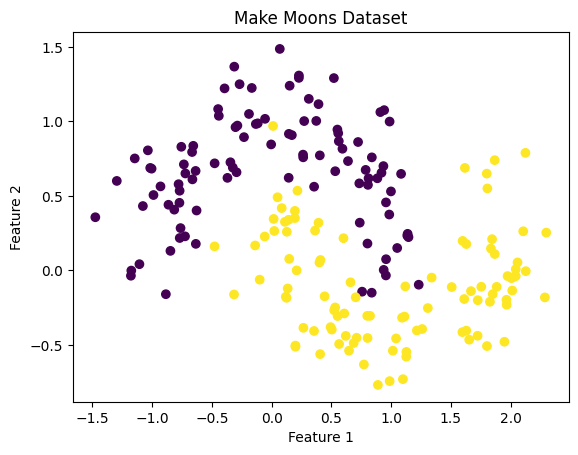

In [9]:
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Make Moons Dataset")
plt.show()

In [10]:
model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

In [11]:
def plot_decision_boundary(model, X, y, title):

    x_min = X[:, 0].min() - 0.5
    x_max = X[:, 0].max() + 0.5

    y_min = X[:, 1].min() - 0.5
    y_max = X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    grid_tensor = torch.tensor(
        grid,
        dtype=torch.float32
    )

    with torch.no_grad():

        predictions = model(grid_tensor)

        predictions = (
            predictions.numpy()
            .reshape(xx.shape)
        )

    plt.contourf(
        xx,
        yy,
        predictions,
        levels=[0, 0.5, 1],
        alpha=0.3
    )

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)

    plt.show()

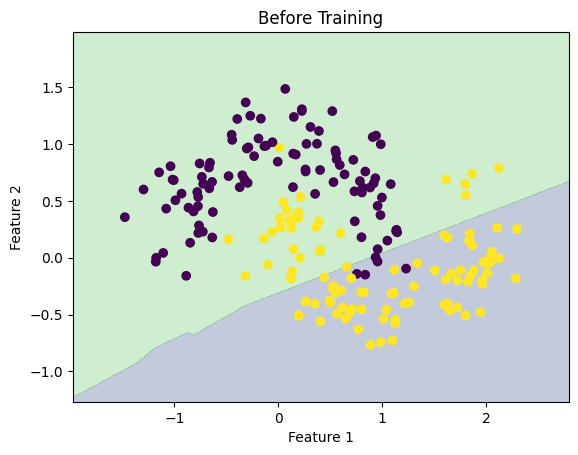

In [12]:
plot_decision_boundary(
    model,
    X,
    y,
    "Before Training"
)

In [15]:
criterion = nn.BCELoss()

In [16]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1
)

In [17]:
loss_history = []

epochs = 500

for epoch in range(epochs):

    # 1. Forward pass
    predictions = model(X_tensor)

    # 2. Calculate loss
    loss = criterion(
        predictions,
        y_tensor
    )

    # 3. Clear previous gradients
    optimizer.zero_grad()

    # 4. Get gradients
    loss.backward()

    # 5. Gradient descent update
    optimizer.step()

    # Save loss
    loss_history.append(
        loss.item()
    )

    if epoch % 100 == 0:

        print(
            f"Epoch {epoch}: "
            f"Loss = {loss.item():.4f}"
        )

Epoch 0: Loss = 0.7401
Epoch 100: Loss = 0.4403
Epoch 200: Loss = 0.3669
Epoch 300: Loss = 0.3294
Epoch 400: Loss = 0.3129


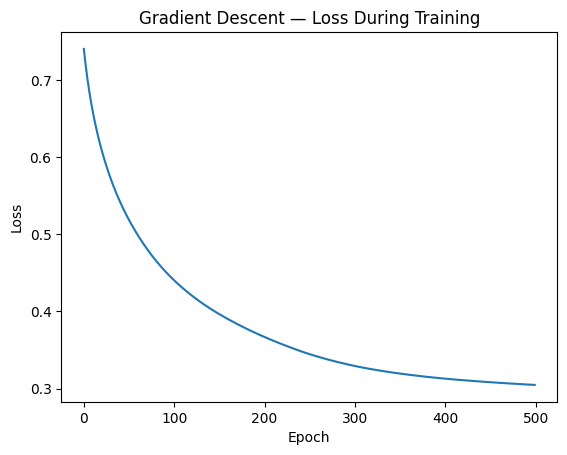

In [18]:
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Gradient Descent — Loss During Training"
)

plt.show()

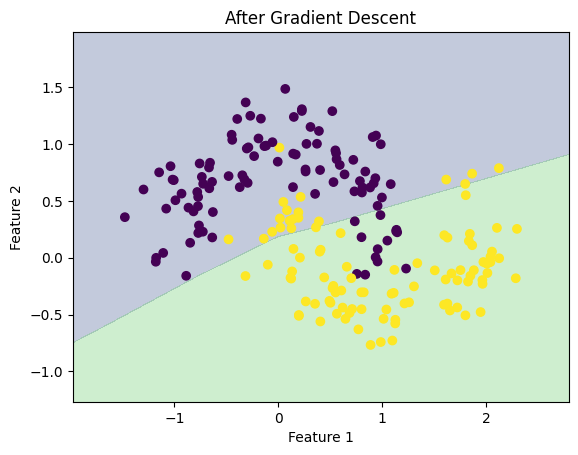

In [19]:
plot_decision_boundary(
    model,
    X,
    y,
    "After Gradient Descent"
)

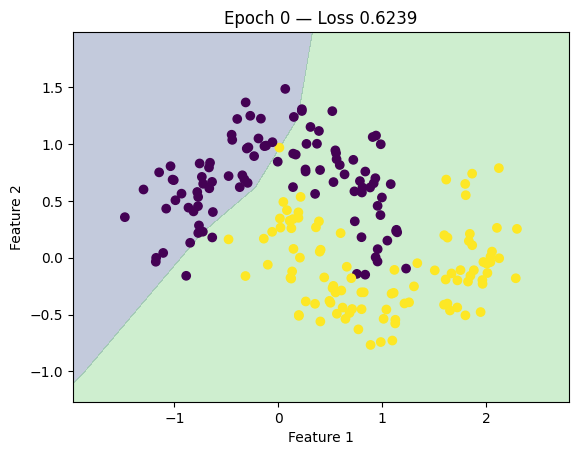

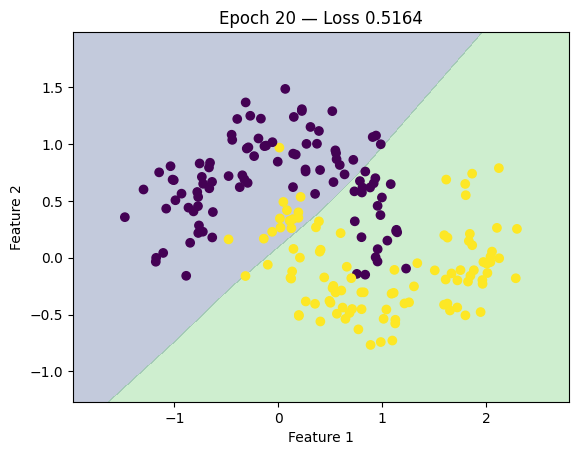

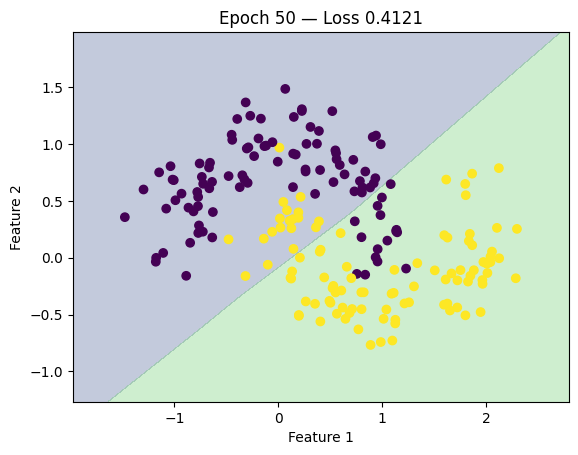

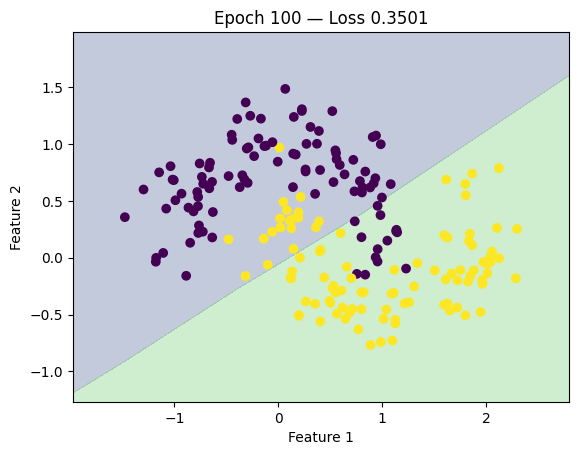

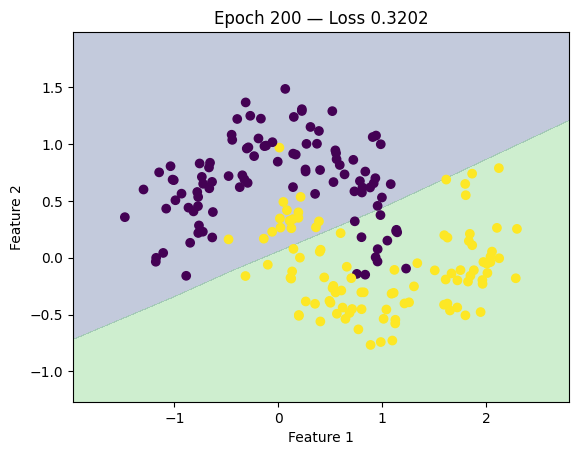

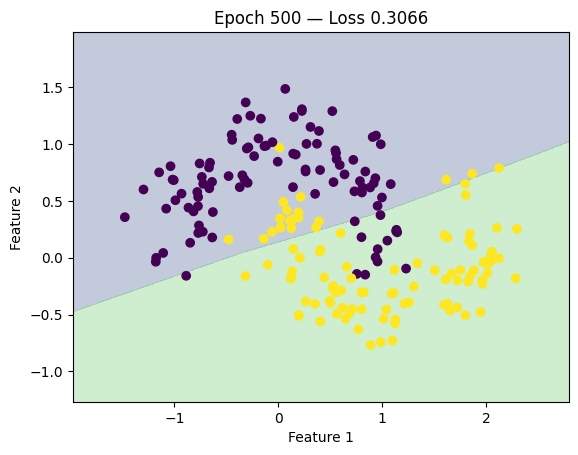

In [20]:
model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1
)

criterion = nn.BCELoss()

checkpoints = [
    0,
    20,
    50,
    100,
    200,
    500
]

for epoch in range(501):

    predictions = model(X_tensor)

    loss = criterion(
        predictions,
        y_tensor
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch in checkpoints:

        plot_decision_boundary(
            model,
            X,
            y,
            f"Epoch {epoch} — Loss {loss.item():.4f}"
        )